# Controller Comparison: Rule-Based vs. PID

This notebook compares two classical HVAC controllers before introducing reinforcement learning.

## Controllers

**Rule-based thermostat** — a simple bang-bang controller:
- If indoor temp > setpoint + deadband → cool
- If indoor temp < setpoint − deadband → heat
- Otherwise → off

**PID controller** — a proportional-integral-derivative controller:
- Computes a continuous error signal (temp − setpoint)
- Combines proportional, integral, and derivative terms to produce a smooth action
- Better at avoiding overshoot and oscillation than bang-bang control

## Why compare these first?

Classical controllers are the incumbents in HVAC. Before claiming that RL adds value, we need to understand what the baseline looks like — and where classical approaches fall short (e.g., not adapting to changing outdoor conditions or occupancy patterns).

The PID controller should outperform the rule-based one. The RL agent (in `train_ppo.ipynb`) will then try to beat both.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from rl_hvac_control.env.hvac_env import SimpleHVACEnv
from rl_hvac_control.controllers.rule_controller import RuleBasedThermostat
from rl_hvac_control.controllers.pid_controller import PIDController

## Run both controllers

Each controller runs for 100 steps on the same environment. We record indoor temperature and cumulative reward at each step.

In [2]:
def run_controller(env, controller, steps=100):
    """Run a controller for `steps` steps, return (temps, rewards)."""
    obs, _ = env.reset()
    temps = []
    rewards = []

    for _ in range(steps):
        action = controller.act(obs)
        obs, reward, done, _, _ = env.step(action)
        temps.append(obs[0])
        rewards.append(reward)

    return temps, rewards

In [3]:
env = SimpleHVACEnv()

rule = RuleBasedThermostat()
pid  = PIDController()

rule_temps, rule_rewards = run_controller(env, rule)
pid_temps,  pid_rewards  = run_controller(env, pid)

## Temperature comparison

The green band is the comfort zone [21–23°C]. Time spent inside this band = comfortable occupants.

Notice how the rule-based controller tends to oscillate — it overshoots in one direction, then corrects, then overshoots again. The PID controller dampens this oscillation.

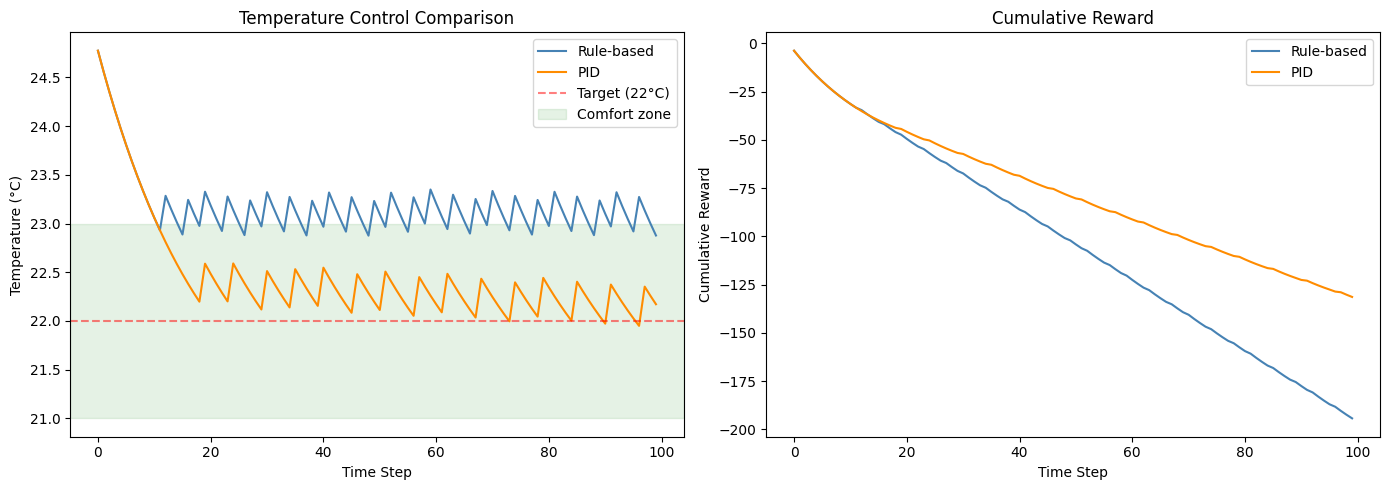

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature
axes[0].plot(rule_temps, label="Rule-based", color='steelblue')
axes[0].plot(pid_temps, label="PID", color='darkorange')
axes[0].axhline(22, linestyle='--', color='red', alpha=0.5, label='Target (22°C)')
axes[0].axhspan(21, 23, alpha=0.1, color='green', label='Comfort zone')
axes[0].set_title("Temperature Control Comparison")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

# Cumulative reward
axes[1].plot(np.cumsum(rule_rewards), label="Rule-based", color='steelblue')
axes[1].plot(np.cumsum(pid_rewards), label="PID", color='darkorange')
axes[1].set_title("Cumulative Reward")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Cumulative Reward")
axes[1].legend()

plt.tight_layout()
plt.show()

## Metrics summary

Three metrics capture the trade-off between comfort and efficiency:
- **Total reward** — higher is better; penalizes comfort violations and energy use
- **Steps in comfort zone** — more is better
- **Comfort violations** — sum of degrees outside [21, 23°C] across all steps

In [5]:
def comfort_steps(temps):
    return sum(21 <= t <= 23 for t in temps)

def comfort_violations(temps):
    return sum(max(0, 21 - t) + max(0, t - 23) for t in temps)

print("=" * 50)
print(f"{'Metric':<30} {'Rule':>8} {'PID':>8}")
print("=" * 50)
print(f"{'Total reward':<30} {sum(rule_rewards):>8.1f} {sum(pid_rewards):>8.1f}")
print(f"{'Steps in comfort zone (/100)':<30} {comfort_steps(rule_temps):>8d} {comfort_steps(pid_temps):>8d}")
print(f"{'Comfort violations (°C·steps)':<30} {comfort_violations(rule_temps):>8.2f} {comfort_violations(pid_temps):>8.2f}")
print("=" * 50)

Metric                             Rule      PID
Total reward                     -194.3   -131.4
Steps in comfort zone (/100)         25       89
Comfort violations (°C·steps)     20.12     9.37


## Summary

The PID controller outperforms the rule-based thermostat on all three metrics. It achieves more timesteps in the comfort zone with fewer oscillations, translating to a higher total reward.

However, both controllers are **hand-engineered** — their parameters are tuned by humans and do not adapt to the environment. The RL agent in `train_ppo.ipynb` learns its policy entirely from experience, potentially discovering patterns neither classical controller exploits.

**Next**: `train_ppo.ipynb` — train the PPO agent.